In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = '{:.5f}'.format

In [ ]:
# import numpy as np
# import pandas as pd

# # -----------------------------
# # 1. Biological Scoring Logic
# # -----------------------------
# def _range_plateau_score(x, low, high, edge_sigma=1.5):
#     # Ensure x is at least 1D (fixes the 0-dimensional error)
#     x = np.atleast_1d(x) 
    
#     score = np.ones_like(x, dtype=float)
#     below = x < low
#     above = x > high
    
#     # These lines now work because score is at least 1D
#     score[below] = np.exp(-0.5 * ((low - x[below]) / edge_sigma) ** 2)
#     score[above] = np.exp(-0.5 * ((x[above] - high) / edge_sigma) ** 2)
    
#     return score

# def _apply_penalties(score, row, species="porcini"):
#     # Apply hard biological limits from your documentation
#     p = 1.0
#     t = row["air_temp_day_avg"]
#     rain = row["rainfall_7d_total"]
    
#     # Heat limits
#     if t > 28: p *= 0.50  # Growth suppressed
#     if species == "porcini" and t > 32: p *= 0.10 # Fruiting stops
    
#     # Saturation/Drought
#     if rain > 60: p *= 0.60 # Soil saturation
#     if row["soil_moisture_avg"] < 45: p *= 0.40 # Too dry
    
#     return score * p

# # -----------------------------
# # 2. Weather Sampling with Anomalies
# # -----------------------------
# def _sample_weather(month, rng):
#     # Base seasonal weather logic
#     if month in [5, 6, 9, 10]: # Peak
#         t, r, h = rng.normal(18.5, 3), rng.normal(25, 10), rng.normal(85, 5)
#     elif month in [7, 8]: # Summer
#         t, r, h = rng.normal(26, 4), rng.normal(12, 10), rng.normal(65, 10)
#     else: # Winter/Shoulder
#         t, r, h = rng.normal(8, 5), rng.normal(15, 8), rng.normal(75, 10)

#     # --- THE BIOLOGICAL STRESSOR (20% chance) ---
#     if rng.random() < 0.20:
#         stress = rng.choice(["drought", "heatwave", "deluge"])
#         if stress == "drought": r, h = 0, rng.uniform(30, 50)
#         elif stress == "heatwave": t = rng.uniform(31, 38)
#         elif stress == "deluge": r = rng.uniform(70, 110)

#     return {
#         "month": int(month),
#         "air_temp_day_avg": np.clip(t, -5, 40),
#         "air_temp_night_avg": np.clip(t - rng.uniform(4, 8), -10, 25),
#         "soil_temp_avg": np.clip(t - rng.uniform(1, 3), 0, 25),
#         "soil_moisture_avg": np.clip(rng.normal(70, 15) if r > 10 else 40, 10, 100),
#         "air_humidity_avg": np.clip(h, 30, 100),
#         "wind_speed_avg": np.clip(np.abs(rng.normal(2, 1.5)), 0, 12),
#         "rainfall_3d_total": np.clip(r * 0.6, 0, 100),
#         "rainfall_7d_total": np.clip(r, 0, 130),
#         "rain_days_7d": int(np.clip(r/5, 0, 7)),
#         "max_daily_rain_7d": np.clip(r * 0.7, 0, 100)
#     }

# # -----------------------------
# # 3. Main Scoring function
# # -----------------------------
# def _compute_score(row, species="porcini"):
#     # 1. Individual Suitability (0.0 to 1.0)
#     # We use a very sharp sigma (0.5) to make the "cliff" brutal.
#     t_opt = (15, 22) if species == "porcini" else (14, 22)
    
#     t_suit = _range_plateau_score(row["air_temp_day_avg"], t_opt[0], t_opt[1], edge_sigma=0.5)[0]
#     r_suit = _range_plateau_score(row["rainfall_7d_total"], 15, 40, edge_sigma=2.0)[0]
#     m_suit = _range_plateau_score(row["soil_moisture_avg"], 60, 85, edge_sigma=5.0)[0]

#     # 2. THE MULTIPLIER (The biological "AND" gate)
#     # If t_suit is 0.1, the max score possible is 10%, no matter how much rain falls.
#     combined_score = t_suit * r_suit * m_suit
    
#     # 3. Hard Biological Kill-Switches
#     temp = row["air_temp_day_avg"]
#     rain = row["rainfall_7d_total"]
#     penalty = 1.0
    
#     # If it is below the biological minimum, force it to zero.
#     if species == "porcini" and temp < 14.5: penalty = 0.05 
#     if species == "chanterelle" and temp < 13.0: penalty = 0.05
    
#     # If there is no rain, it's a 0.
#     if rain < 5: penalty = 0.0
    
#     final_score = combined_score * penalty * 100
#     return float(np.clip(final_score, 0, 100))

# def generate_dataset(n=10000, seed=42):
#     rng = np.random.default_rng(seed)
#     data = []
#     months = [1,2,3,4,5,6,7,8,9,10,11,12]
#     probs = [0.03, 0.03, 0.04, 0.08, 0.15, 0.15, 0.05, 0.05, 0.20, 0.15, 0.05, 0.02]
    
#     for _ in range(n):
#         m = rng.choice(months, p=probs)
#         row = _sample_weather(m, rng)
#         row["porcini_growth_score"] = _compute_score(row, "porcini")
#         row["chanterelle_growth_score"] = _compute_score(row, "chanterelle")
#         data.append(row)
        
#     return pd.DataFrame(data)

# df = generate_dataset(50000)


In [ ]:
import numpy as np
import pandas as pd


# -----------------------------
# Utility scoring functions
# -----------------------------
def _gaussian_score(x, center, sigma):
    """
    Smooth score in [0, 1], highest near center.
    """
    return np.exp(-0.5 * ((x - center) / sigma) ** 2)


def _range_plateau_score(x, low, high, edge_sigma=2.0):
    """
    Score in [0,1]:
    - near 1 inside [low, high]
    - decays smoothly outside
    """
    x = np.asarray(x)
    score = np.ones_like(x, dtype=float)

    below = x < low
    above = x > high

    score[below] = np.exp(-0.5 * ((low - x[below]) / edge_sigma) ** 2)
    score[above] = np.exp(-0.5 * ((x[above] - high) / edge_sigma) ** 2)
    return score


def _season_score(month, peak_months, shoulder_months, off_value=0.15):
    """
    Smooth-ish season score based on month.
    """
    if month in peak_months:
        return 1.0
    if month in shoulder_months:
        return 0.65
    return off_value


def _apply_penalties(score, penalties):
    """
    Multiply score by all penalty factors.
    """
    for p in penalties:
        score *= p
    return score


def _clip_0_100(x):
    return np.clip(x, 0.0, 100.0)


# -----------------------------
# Feature generation helpers
# -----------------------------
def _sample_month(rng):
    """
    Full-year generation with controlled season preference.
    More likely to sample in/near mushroom season,
    but still covers the full year.
    """
    months = np.arange(1, 13)
    probs = np.array([
        0.04,  # Jan
        0.04,  # Feb
        0.05,  # Mar
        0.06,  # Apr
        0.12,  # May
        0.12,  # Jun
        0.07,  # Jul
        0.08,  # Aug
        0.16,  # Sep
        0.16,  # Oct
        0.06,  # Nov
        0.04   # Dec
    ], dtype=float)
    probs /= probs.sum()
    return rng.choice(months, p=probs)


def _sample_features_for_month(month, rng):
    """
    Generate a hybrid aggregated observation window.
    Values are realistic-ish but still synthetic.
    """

    # Month-conditioned centers to create seasonality in features
    if month in [5, 6]:  # late spring / early summer
        day_temp = rng.normal(19, 4)
        night_temp = rng.normal(12.5, 3)
        soil_temp = rng.normal(16.5, 2.5)
        humidity = rng.normal(84, 8)
        soil_moisture = rng.normal(70, 10)
        wind = np.abs(rng.normal(2.0, 1.2))
        rain_7d = max(0, rng.normal(24, 14))
    elif month in [9, 10]:  # autumn peak
        day_temp = rng.normal(17, 4)
        night_temp = rng.normal(11.5, 3)
        soil_temp = rng.normal(15.5, 2.5)
        humidity = rng.normal(87, 7)
        soil_moisture = rng.normal(72, 10)
        wind = np.abs(rng.normal(2.0, 1.1))
        rain_7d = max(0, rng.normal(28, 15))
    elif month in [7, 8]:  # summer, can be too hot
        day_temp = rng.normal(25, 5)
        night_temp = rng.normal(16, 3.5)
        soil_temp = rng.normal(20, 3)
        humidity = rng.normal(70, 12)
        soil_moisture = rng.normal(55, 12)
        wind = np.abs(rng.normal(2.5, 1.5))
        rain_7d = max(0, rng.normal(16, 18))
    elif month in [11, 4]:  # shoulder months
        day_temp = rng.normal(13, 5)
        night_temp = rng.normal(8, 4)
        soil_temp = rng.normal(11.5, 3)
        humidity = rng.normal(80, 10)
        soil_moisture = rng.normal(68, 11)
        wind = np.abs(rng.normal(2.3, 1.3))
        rain_7d = max(0, rng.normal(18, 14))
    else:  # winter / low season
        day_temp = rng.normal(6, 6)
        night_temp = rng.normal(1, 5)
        soil_temp = rng.normal(5, 4)
        humidity = rng.normal(78, 12)
        soil_moisture = rng.normal(65, 12)
        wind = np.abs(rng.normal(3.0, 1.7))
        rain_7d = max(0, rng.normal(14, 14))

    # Derived rainfall structure
    rain_3d = np.clip(rain_7d * rng.uniform(0.25, 0.8), 0, rain_7d)

    # Rain pattern: light continuous rain better than one storm
    if rain_7d < 3:
        rain_days_7d = rng.integers(0, 2)
    else:
        rain_days_7d = int(np.clip(np.round(rng.normal(4, 2)), 1, 7))

    # Decide whether rainfall is spread or concentrated
    concentrated = rng.random() < 0.25
    if concentrated:
        max_daily_rain_7d = np.clip(rain_7d * rng.uniform(0.45, 0.9), 0, 120)
    else:
        max_daily_rain_7d = np.clip(rain_7d / max(rain_days_7d, 1) * rng.uniform(1.0, 1.8), 0, 60)

    # Clamp biologically plausible ranges
    humidity = np.clip(humidity, 35, 100)
    soil_moisture = np.clip(soil_moisture, 15, 100)
    wind = np.clip(wind, 0, 12)
    day_temp = np.clip(day_temp, -5, 40)
    night_temp = np.clip(night_temp, -10, 28)
    soil_temp = np.clip(soil_temp, -2, 30)
    rain_3d = np.clip(rain_3d, 0, 90)
    rain_7d = np.clip(rain_7d, 0, 140)

    return {
        "month": int(month),
        "air_temp_day_avg": float(day_temp),
        "air_temp_night_avg": float(night_temp),
        "soil_temp_avg": float(soil_temp),
        "soil_moisture_avg": float(soil_moisture),
        "air_humidity_avg": float(humidity),
        "wind_speed_avg": float(wind),
        "rainfall_3d_total": float(rain_3d),
        "rainfall_7d_total": float(rain_7d),
        "rain_days_7d": int(rain_days_7d),
        "max_daily_rain_7d": float(max_daily_rain_7d),
    }


# -----------------------------
# Target scoring
# -----------------------------
def _compute_species_score(row, species="porcini"):
    """
    Transparent synthetic biological scoring.
    Returns pre-noise score in [0,100].
    """

    month = row["month"]
    day_temp = row["air_temp_day_avg"]
    night_temp = row["air_temp_night_avg"]
    soil_temp = row["soil_temp_avg"]
    soil_m = row["soil_moisture_avg"]
    humidity = row["air_humidity_avg"]
    wind = row["wind_speed_avg"]
    rain_3d = row["rainfall_3d_total"]
    rain_7d = row["rainfall_7d_total"]
    rain_days = row["rain_days_7d"]
    max_daily_rain = row["max_daily_rain_7d"]

    if species == "porcini":
        weights = {
            "day_temp": 0.18,
            "night_temp": 0.10,
            "soil_temp": 0.14,
            "soil_moisture": 0.13,
            "humidity": 0.11,
            "wind": 0.07,
            "rain_trigger": 0.16,
            "rain_pattern": 0.05,
            "season": 0.06,
        }

        peak_months = {5, 6, 9, 10}
        shoulder_months = {4, 7, 8, 11}

        day_temp_score = _range_plateau_score(np.array([day_temp]), 15, 22, edge_sigma=3.0)[0]
        night_temp_score = _range_plateau_score(np.array([night_temp]), 10, 16, edge_sigma=2.5)[0]
        soil_temp_score = _range_plateau_score(np.array([soil_temp]), 14, 20, edge_sigma=2.2)[0]
        soil_m_score = _range_plateau_score(np.array([soil_m]), 60, 80, edge_sigma=8.0)[0]
        humidity_score = _range_plateau_score(np.array([humidity]), 75, 95, edge_sigma=8.0)[0]
        wind_score = _range_plateau_score(np.array([wind]), 1, 3, edge_sigma=1.2)[0]

        rain_3d_score = _range_plateau_score(np.array([rain_3d]), 10, 22, edge_sigma=7.0)[0]
        rain_7d_score = _range_plateau_score(np.array([rain_7d]), 15, 30, edge_sigma=10.0)[0]
        rain_trigger_score = 0.45 * rain_3d_score + 0.55 * rain_7d_score

        spread_bonus = _range_plateau_score(np.array([rain_days]), 3, 6, edge_sigma=1.5)[0]
        storm_penalty_component = _range_plateau_score(np.array([max_daily_rain]), 0, 20, edge_sigma=8.0)[0]
        rain_pattern_score = 0.6 * spread_bonus + 0.4 * storm_penalty_component

        season_score = _season_score(month, peak_months, shoulder_months, off_value=0.10)

        base_score = (
            weights["day_temp"] * day_temp_score +
            weights["night_temp"] * night_temp_score +
            weights["soil_temp"] * soil_temp_score +
            weights["soil_moisture"] * soil_m_score +
            weights["humidity"] * humidity_score +
            weights["wind"] * wind_score +
            weights["rain_trigger"] * rain_trigger_score +
            weights["rain_pattern"] * rain_pattern_score +
            weights["season"] * season_score
        )

        penalties = []

        # Heat penalties
        if day_temp > 28:
            penalties.append(0.55)
        if day_temp > 32:
            penalties.append(0.15)

        # Minimum-ish penalties
        if day_temp < 10:
            penalties.append(0.45)
        if night_temp < 5:
            penalties.append(0.65)
        if soil_temp < 8:
            penalties.append(0.55)

        # Heavy rain / saturation
        if rain_7d > 60:
            penalties.append(0.55)
        if max_daily_rain > 35:
            penalties.append(0.70)

        # Dryness
        if soil_m < 45:
            penalties.append(0.45)
        if humidity < 60:
            penalties.append(0.65)

        # Strong wind
        if wind > 6:
            penalties.append(0.75)

    else:  # chanterelle
        weights = {
            "day_temp": 0.16,
            "night_temp": 0.10,
            "soil_temp": 0.14,
            "soil_moisture": 0.14,
            "humidity": 0.14,
            "wind": 0.07,
            "rain_trigger": 0.12,
            "rain_pattern": 0.07,
            "season": 0.06,
        }

        peak_months = {5, 6, 9, 10}
        shoulder_months = {4, 7, 8, 11}

        day_temp_score = _range_plateau_score(np.array([day_temp]), 14, 22, edge_sigma=3.3)[0]
        night_temp_score = _range_plateau_score(np.array([night_temp]), 10, 16, edge_sigma=2.8)[0]
        soil_temp_score = _range_plateau_score(np.array([soil_temp]), 14, 20, edge_sigma=2.5)[0]
        soil_m_score = _range_plateau_score(np.array([soil_m]), 60, 80, edge_sigma=8.5)[0]
        humidity_score = _range_plateau_score(np.array([humidity]), 75, 95, edge_sigma=7.5)[0]
        wind_score = _range_plateau_score(np.array([wind]), 1, 3, edge_sigma=1.3)[0]

        rain_3d_score = _range_plateau_score(np.array([rain_3d]), 10, 24, edge_sigma=7.5)[0]
        rain_7d_score = _range_plateau_score(np.array([rain_7d]), 15, 32, edge_sigma=10.0)[0]
        rain_trigger_score = 0.35 * rain_3d_score + 0.65 * rain_7d_score

        spread_bonus = _range_plateau_score(np.array([rain_days]), 3, 6, edge_sigma=1.5)[0]
        storm_penalty_component = _range_plateau_score(np.array([max_daily_rain]), 0, 22, edge_sigma=8.5)[0]
        rain_pattern_score = 0.55 * spread_bonus + 0.45 * storm_penalty_component

        season_score = _season_score(month, peak_months, shoulder_months, off_value=0.12)

        base_score = (
            weights["day_temp"] * day_temp_score +
            weights["night_temp"] * night_temp_score +
            weights["soil_temp"] * soil_temp_score +
            weights["soil_moisture"] * soil_m_score +
            weights["humidity"] * humidity_score +
            weights["wind"] * wind_score +
            weights["rain_trigger"] * rain_trigger_score +
            weights["rain_pattern"] * rain_pattern_score +
            weights["season"] * season_score
        )

        penalties = []

        if day_temp > 28:
            penalties.append(0.60)
        if day_temp < 10:
            penalties.append(0.50)
        if night_temp < 5:
            penalties.append(0.70)
        if soil_temp < 8:
            penalties.append(0.60)

        if rain_7d > 60:
            penalties.append(0.60)
        if max_daily_rain > 35:
            penalties.append(0.75)

        if soil_m < 45:
            penalties.append(0.50)
        if humidity < 60:
            penalties.append(0.55)

        if wind > 6:
            penalties.append(0.78)

    score = base_score * 100.0
    score = _apply_penalties(score, penalties)
    return float(_clip_0_100(score))


# -----------------------------
# Noise model
# -----------------------------
def _resolve_noise_scale(noise_level, score):
    """
    Returns std deviation in score points.
    Can be string or numeric.
    """
    if isinstance(noise_level, str):
        level = noise_level.lower()
        if level == "low":
            base = 3.0
        elif level == "medium":
            base = 6.0
        elif level == "high":
            base = 10.0
        elif level == "dynamic":
            # More noise in mid-range / uncertain areas, less at extremes
            # score is in [0,100]
            # peaks around 50
            base = 2.5 + 5.5 * np.exp(-((score - 50.0) ** 2) / (2 * 18.0 ** 2))
        else:
            raise ValueError("noise_level must be 'low', 'medium', 'high', 'dynamic', or a numeric value.")
    else:
        base = float(noise_level)

    return base


# -----------------------------
# Single-row generation
# -----------------------------
def _generate_one_row(rng, noise_level="dynamic"):
    month = _sample_month(rng)
    row = _sample_features_for_month(month, rng)

    porcini_score = _compute_species_score(row, "porcini")
    chanterelle_score = _compute_species_score(row, "chanterelle")

    # correlated label noise so outputs are not totally independent
    shared_noise = rng.normal(0, 1)

    p_sigma = _resolve_noise_scale(noise_level, porcini_score)
    c_sigma = _resolve_noise_scale(noise_level, chanterelle_score)

    porcini_noisy = porcini_score + 0.65 * shared_noise * p_sigma + rng.normal(0, p_sigma * 0.55)
    chanterelle_noisy = chanterelle_score + 0.65 * shared_noise * c_sigma + rng.normal(0, c_sigma * 0.55)

    row["porcini_growth_score"] = float(_clip_0_100(porcini_noisy))
    row["chanterelle_growth_score"] = float(_clip_0_100(chanterelle_noisy))
    return row


# -----------------------------
# Balancing
# -----------------------------
def _bucketize(x):
    if x < 33.33:
        return "low"
    if x < 66.66:
        return "medium"
    return "high"


def _balance_per_target(df, target_col, n_target, rng):
    """
    Approximate balancing per target separately.
    """
    df = df.copy()
    df["_bucket"] = df[target_col].apply(_bucketize)

    low_df = df[df["_bucket"] == "low"]
    med_df = df[df["_bucket"] == "medium"]
    high_df = df[df["_bucket"] == "high"]

    per_bucket = n_target // 3
    remainder = n_target - per_bucket * 3

    parts = []
    for bucket_df, need in zip([low_df, med_df, high_df], [per_bucket, per_bucket, per_bucket + remainder]):
        if len(bucket_df) == 0:
            continue
        replace = len(bucket_df) < need
        idx = rng.choice(bucket_df.index.to_numpy(), size=need, replace=replace)
        parts.append(bucket_df.loc[idx])

    out = pd.concat(parts, axis=0).drop(columns=["_bucket"], errors="ignore")
    out = out.sample(frac=1.0, random_state=int(rng.integers(0, 1_000_000))).reset_index(drop=True)
    return out


def _dual_balance(df, n_target, rng):
    """
    First balance on porcini, then lightly rebalance on chanterelle.
    This is approximate, not perfect joint balancing.
    """
    tmp = _balance_per_target(df, "porcini_growth_score", max(n_target * 2, n_target), rng)
    tmp = _balance_per_target(tmp, "chanterelle_growth_score", n_target, rng)
    return tmp


# -----------------------------
# Main public generator
# -----------------------------
def generate_mushroom_growth_dataset(
    n_samples=10000,
    seed=42,
    noise_level="dynamic",
    balance=True,
    oversample_factor=6,
):
    """
    Generate a synthetic pandas DataFrame for multi-output mushroom growth regression.

    Parameters
    ----------
    n_samples : int
        Number of rows in the final dataset.
    seed : int
        Random seed for reproducibility.
    noise_level : str or float
        'low', 'medium', 'high', 'dynamic', or numeric std-dev in score points.
    balance : bool
        Whether to approximately balance score ranges per target.
    oversample_factor : int
        How many raw rows to generate before balancing.
        Increase if balancing quality is poor.

    Returns
    -------
    pd.DataFrame
        DataFrame with features + two target columns.
    """
    rng = np.random.default_rng(seed)

    raw_n = n_samples * oversample_factor if balance else n_samples
    rows = [_generate_one_row(rng, noise_level=noise_level) for _ in range(raw_n)]
    df = pd.DataFrame(rows)

    if balance:
        df = _dual_balance(df, n_samples, rng)
    else:
        df = df.sample(n=n_samples, random_state=seed).reset_index(drop=True)

    # final column order
    cols = [
        "month",
        "air_temp_day_avg",
        "air_temp_night_avg",
        "soil_temp_avg",
        "soil_moisture_avg",
        "air_humidity_avg",
        "wind_speed_avg",
        "rainfall_3d_total",
        "rainfall_7d_total",
        "rain_days_7d",
        "max_daily_rain_7d",
        "porcini_growth_score",
        "chanterelle_growth_score",
    ]
    return df[cols]


# -----------------------------
# Example usage

df = generate_mushroom_growth_dataset(
        n_samples=50000,
        seed=123,
        noise_level="dynamic",   # "low", "medium", "high", "dynamic", or e.g. 5.0
        balance=True,
        oversample_factor=8
    )


In [33]:
df.head()

,month,air_temp_day_avg,air_temp_night_avg,soil_temp_avg,soil_moisture_avg,air_humidity_avg,wind_speed_avg,rainfall_3d_total,rainfall_7d_total,rain_days_7d,max_daily_rain_7d,porcini_growth_score,chanterelle_growth_score
0,6,18.633271,9.755159,16.110991,72.595512,88.947361,1.076511,19.891302,37.171958,0,29.737567,100.000000,100.00000
1,8,24.487355,19.351161,22.378185,15.240162,46.455232,4.224340,1.897790,3.219326,3,2.575460,0.000000,0.00000
2,9,18.127156,13.153962,16.193714,82.775381,92.862422,1.194303,23.842084,39.413960,5,31.531168,100.000000,100.00000
3,5,21.805058,16.857702,20.545215,51.373196,82.409194,1.521092,15.934941,26.516507,3,21.213206,22.374869,23.44058
4,9,23.828747,15.804926,22.053791,27.438874,36.247333,3.571230,1.547326,3.501326,5,2.801060,0.000000,0.00000


In [43]:
df.to_csv("data.csv")

In [35]:
df[(df["porcini_growth_score"] == 0) & (df["chanterelle_growth_score"] > 5)]

,month,air_temp_day_avg,air_temp_night_avg,soil_temp_avg,soil_moisture_avg,air_humidity_avg,wind_speed_avg,rainfall_3d_total,rainfall_7d_total,rain_days_7d,max_daily_rain_7d,porcini_growth_score,chanterelle_growth_score
9,6,12.874243,5.722830,11.150617,55.605908,79.525531,1.031027,22.987671,33.384688,2,26.707751,0.0,26.630582
44,8,12.969333,5.887788,11.884632,92.798349,85.288590,3.693102,22.328531,49.406144,0,39.524915,0.0,18.808218
61,5,13.136274,8.931540,10.581588,78.543375,78.662322,4.934931,22.928145,42.499506,0,33.999605,0.0,68.865774
73,7,12.887328,6.804280,11.884007,66.332561,77.551789,4.382441,10.493942,26.210616,2,20.968493,0.0,53.847220
77,10,13.973586,5.696129,12.465059,74.867712,74.068587,2.545058,22.412300,38.573573,5,30.858858,0.0,99.965122
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49805,5,13.788840,5.270967,11.125715,75.859212,88.167880,1.319940,20.781206,40.812342,0,32.649874,0.0,97.795240
49814,7,13.109456,5.982176,10.827492,71.996469,72.443538,2.327275,11.733593,28.544111,0,22.835289,0.0,67.264711
49917,8,12.660558,4.103302,9.946777,62.975422,83.616046,1.222043,12.623547,25.515394,4,20.412315,0.0,39.491861
49954,10,13.638630,5.786509,12.080466,84.612545,81.685213,2.449312,19.963518,48.414861,4,38.731889,0.0,49.010156


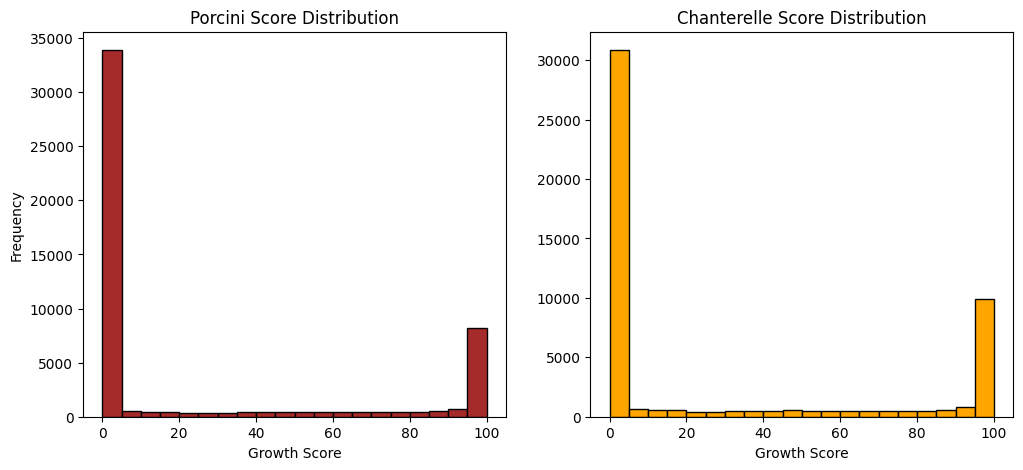

In [41]:
import matplotlib.pyplot as plt

def check_balance(df):
    plt.figure(figsize=(12, 5))
    
    # Porcini Distribution
    plt.subplot(1, 2, 1)
    plt.hist(df['porcini_growth_score'], bins=20, color='brown', edgecolor='black')
    plt.title('Porcini Score Distribution')
    plt.xlabel('Growth Score')
    plt.ylabel('Frequency')
    
    # Chanterelle Distribution
    plt.subplot(1, 2, 2)
    plt.hist(df['chanterelle_growth_score'], bins=20, color='orange', edgecolor='black')
    plt.title('Chanterelle Score Distribution')
    plt.xlabel('Growth Score')
    
    plt.show()

check_balance(df)

In [37]:
# Check what percentage of the data results in zero growth
zeros_p = (df['porcini_growth_score'] == 0).mean() * 100
zeros_c = (df['chanterelle_growth_score'] == 0).mean() * 100

print(f"Percentage of Zero-Growth samples (Porcini): {zeros_p:.2f}%")
print(f"Percentage of Zero-Growth samples (Chanterelle): {zeros_c:.2f}%")

Percentage of Zero-Growth samples (Porcini): 45.85%
Percentage of Zero-Growth samples (Chanterelle): 39.49%


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/growth_data.csv")

In [4]:
df[['porcini_growth_score', 'chanterelle_growth_score']].describe()

,porcini_growth_score,chanterelle_growth_score
count,50000.000000,50000.000000
mean,48.023746,51.568801
std,31.741613,30.862453
min,0.000000,0.000000
25%,18.977326,24.166564
50%,42.889477,46.718856
75%,80.616669,83.696748
max,100.000000,100.000000
